# CNN Consulta  
**Gabriel Salguero**

---

### El problema de la visión artificial tradicional

Durante muchos años, el procesamiento de imágenes mediante algoritmos computacionales fue un desafío significativo. Para un ser humano, interpretar una fotografía es un proceso natural: reconocemos formas, bordes, colores, profundidades y patrones en milisegundos. Pero para una máquina, una imagen no es más que una enorme colección de valores numéricos. Cada píxel representa una intensidad lumínica en una escala de 0 a 255, y una imagen completa es simplemente una matriz bidimensional (o tridimensional si incluye canales de color como RGB).

Las primeras aproximaciones consistieron en utilizar redes neuronales tradicionales, como los Perceptrones Multicapa (MLP). Sin embargo, estas redes tienen una limitación fundamental: **solo pueden recibir vectores unidimensionales como entrada**. Esto obliga a “aplanar” la imagen (flattening), es decir, convertir su matriz de píxeles en una sola fila enorme de números.

Este proceso genera un problema crítico: **se destruye por completo la estructura espacial de la imagen**. La posición relativa de cada píxel —si estaba arriba, abajo, a la izquierda o a la derecha de otro— se pierde por completo. La red recibe los valores, pero deja de saber qué píxeles estaban juntos formando un borde, un contorno o una forma coherente.

Esto provoca dos grandes dificultades:

- **Pérdida del contexto local:** los patrones visuales solo tienen sentido cuando los píxeles vecinos mantienen su relación. Un borde, una esquina o una textura no existen sin esa vecindad.
- **Explosión de parámetros:** al no poder reutilizar información espacial, la red debe aprender desde cero cada patrón posible, lo que multiplica el número de conexiones y dificulta el entrenamiento.

En resumen, las redes neuronales densas tradicionales no están diseñadas para entender imágenes tal como las percibe un humano, porque el proceso de aplanado destruye justamente aquello que hace que una imagen tenga significado: **su estructura espacial**.

![imagen](./img/image.png)

### La operación de Convolución

El concepto central que le da nombre a esta arquitectura es la convolución matemática, adaptada al procesamiento discreto de matrices. En términos prácticos, una convolución consiste en deslizar una pequeña matriz llamada "filtro" o "kernel" a lo largo y ancho de la imagen original.

Este filtro suele tener dimensiones pequeñas, típicamente de 3x3 o 5x5 píxeles. A medida que el filtro se desliza sobre la imagen, se realiza una multiplicación elemento a elemento entre los valores del filtro y los valores de los píxeles de la imagen que están justo debajo de él en ese instante. Luego, todos esos resultados se suman en un único número. Este número resultante se coloca en una nueva matriz, creando lo que se conoce como un "Mapa de Características" (Feature Map).

Este proceso se repite sistemáticamente en toda la imagen, desplazando el filtro píxel por píxel (o según el valor del *stride*, que define el tamaño del paso). De esta forma, se genera una nueva representación de la imagen donde cada valor resume la información local de una región específica de la imagen original.

La principal ventaja de este mecanismo es que **preserva la relación espacial entre los píxeles**, ya que el filtro siempre opera sobre vecindades locales. Esto permite que la red detecte patrones independientemente de su posición exacta dentro de la imagen.

La magia matemática de estos filtros radica en los números que contienen. Dependiendo de la configuración de esos valores, un filtro puede funcionar como un detector de bordes verticales, otro puede detectar bordes horizontales, otro esquinas, y otros texturas o gradientes de color.

En el contexto del aprendizaje profundo, estos filtros no se definen manualmente. En su lugar, la red neuronal aprende automáticamente los valores óptimos durante el entrenamiento mediante el algoritmo de *backpropagation*. A medida que la red ve más ejemplos, ajusta los filtros para capturar las características más relevantes del problema, desde patrones simples en las primeras capas hasta estructuras más complejas en capas profundas.


### Controlando la convolución: Stride y Padding

Al diseñar una capa convolucional, existen dos hiperparámetros esenciales que controlan cómo el filtro recorre físicamente la imagen: **Stride** y **Padding**. Ambos influyen directamente en el tamaño de la salida, la cantidad de información retenida y el costo computacional de la operación.

#### Stride (paso o zancada)

El *stride* define cuántos píxeles se desplaza el filtro cada vez que realiza una operación de convolución.  

- Con **stride = 1**, el filtro avanza píxel por píxel.  
  Esto produce un *Feature Map* muy detallado y solo ligeramente más pequeño que la imagen original. Este es el caso más común, ya que permite capturar patrones finos.

- Con **stride = 2** o mayor, el filtro “salta” más rápido por la imagen.  
  Como resultado, la resolución del mapa de características se reduce, esencialmente realizando un “submuestreo” (downsampling). Aunque esto disminuye el costo computacional, también implica perder información espacial.

El stride, por lo tanto, determina el nivel de detalle con el que la red analiza cada región de la imagen y controla cuán comprimida será la representación final.

#### Padding (relleno)

Al aplicar un filtro de tamaño *k × k*, las regiones del borde de la imagen se ven afectadas de manera distinta a las zonas centrales, recibiendo menos operaciones de convolución. Además, sin padding, la salida siempre se vuelve más pequeña que la entrada (por ejemplo, con un filtro 3×3, una imagen 28×28 se convierte en 26×26).

Para evitar esta reducción y permitir que la red aprenda adecuadamente características presentes en los bordes, se utiliza **Padding**, generalmente añadiendo un marco de ceros alrededor de la imagen, conocido como *zero-padding*.

El padding permite:

- Mantener el mismo tamaño espacial en la salida (*same padding*).  
- Evitar que las características importantes en los bordes se pierdan.  
- Dar más contexto al filtro durante el proceso de convolución.

En conjunto, **Stride y Padding** actúan como los controles de “zoom” y “encuadre” de la convolución, determinando qué tan detallada y qué tan grande será la representación resultante.

![imagen](./img/images.png)

### Capas de Submuestreo (Pooling)

Una vez que las convoluciones han generado múltiples mapas de características, aparece un nuevo problema: el volumen de datos crece rápidamente. Cada filtro produce un mapa adicional y, a medida que la red profundiza, el número total de valores procesados puede volverse enorme. Esto aumenta el uso de memoria, el tiempo de cálculo y el riesgo de que el modelo aprenda detalles excesivamente específicos de la imagen, en lugar de patrones generales.

Para controlar este crecimiento y mejorar la robustez del modelo, se utilizan las **capas de Pooling**, cuyo objetivo principal es reducir la dimensionalidad manteniendo la información más relevante.

#### Max Pooling: el estándar en visión por computadora

El método más común es **Max Pooling**. Su funcionamiento es sencillo:

1. El mapa de características se divide en pequeñas regiones, típicamente de **2×2** píxeles.
2. De cada región, se toma únicamente **el valor más alto**.
3. Los demás valores se descartan.

Este proceso resume la información local conservando solo las activaciones más importantes, reduciendo la matriz resultante a la cuarta parte de su tamaño si se usa un pooling 2×2 con stride 2.

#### ¿Por qué es importante el Pooling?

El Max Pooling cumple dos funciones esenciales:

1. **Reducción drástica de dimensionalidad**  
   Al comprimir los mapas de características, disminuye el costo computacional en las capas posteriores. Esto permite construir redes profundas sin que el hardware colapse.

2. **Invariancia espacial**  
   Al seleccionar solamente la activación más fuerte, el modelo se vuelve menos sensible a pequeños desplazamientos o deformaciones del objeto en la imagen.  
   Por ejemplo, si un borde se mueve ligeramente hacia la izquierda o hacia arriba, su valor máximo seguirá quedando dentro de la ventana de pooling. La red, por lo tanto, continúa reconociendo la característica sin problema.

Este comportamiento es clave para que las CNN generalicen correctamente, ya que las imágenes reales rara vez presentan los objetos en la misma posición exacta.

![imagen2](./img/image2.jpg)

### La abstracción profunda y funciones de activación

Las CNN se consideran parte del *Deep Learning* porque apilan numerosas capas de convolución y pooling, formando una jerarquía progresiva de abstracciones. En las capas iniciales, los filtros aprenden a detectar patrones muy básicos: bordes, líneas, cambios bruscos de intensidad y texturas simples. Estas características de bajo nivel son los “ladrillos” fundamentales del análisis visual.

A medida que avanzamos hacia capas más profundas, las CNN comienzan a combinar estos patrones simples para formar representaciones más complejas: esquinas, curvas, contornos y figuras geométricas. En niveles todavía superiores, estas formas se integran para identificar partes de objetos (como las ruedas de un automóvil, los pétalos de una flor o los rasgos de un rostro). Finalmente, en las capas más profundas, el modelo es capaz de reconocer conceptos de alto nivel sin que nadie se los haya especificado explícitamente.

Esta capacidad de generar abstracción progresiva es lo que hace a las CNN tan potentes, pero solo es posible si la red incorpora **no-linealidad** entre cada capa. Sin no-linealidad, incluso si apiláramos cien capas convolucionales, todo el sistema matemáticamente equivaldría a una sola transformación lineal; es decir, no podría aprender funciones complejas.

Aquí entra en juego la función de activación **ReLU (Rectified Linear Unit)**.

#### ReLU: la no-linealidad que habilitó el Deep Learning moderno

Después de cada convolución, se aplica ReLU, cuya operación es sorprendentemente simple:

- Si el valor es positivo, se mantiene.  
- Si el valor es negativo, se convierte en 0.

A pesar de su simplicidad, ReLU revolucionó el campo del aprendizaje profundo por tres razones:

1. **Introduce no-linealidad**  
   Permite que las capas sucesivas combinen características de manera compleja, lo que habilita el reconocimiento de patrones abstractos.

2. **Filtra ruido**  
   Los valores negativos suelen representar activaciones débiles o poco relevantes, así que al anularlos se obtiene una representación más limpia.

3. **Evita el desvanecimiento del gradiente**  
   Comparada con funciones más antiguas como la sigmoide o la tangente hiperbólica, ReLU permite que el gradiente fluya con mucha más fuerza durante el entrenamiento.  
   Esto hace posibles redes profundas que antes eran prácticamente imposibles de entrenar.

Gracias a la combinación de **abstracción progresiva** + **ReLU**, las CNN pueden aprender conceptos visuales complejos a partir de simples matrices numéricas.

![imagen2](./img/image3.png)

### Clasificación Final: Flatten y Capas Densas

El bloque convolucional completo (Convolución + ReLU + Pooling) cumple la función de analizar la imagen y extraer patrones cada vez más complejos. Sin embargo, todo este procesamiento solo produce **representaciones**, no decisiones. El resultado típico al finalizar esta etapa es un conjunto de pequeños mapas de características organizados en una estructura tridimensional: ancho × alto × profundidad.

Para transformar esta representación en una predicción concreta, la red necesita una etapa final de **clasificación**. Aquí es donde entra en juego el proceso de **Flatten** y las capas densas.

#### Flatten: conectando lo visual con lo simbólico

La operación **Flatten** toma la salida tridimensional del bloque convolucional y la “desenrolla” en un único vector unidimensional.  
Este vector actúa como un resumen de alto nivel de todo lo que la red ha aprendido a detectar: bordes, formas, patrones y conceptos abstractos.

El Flatten es la transición crucial entre:

- **La parte “visual” de la red** (convoluciones y pooling)  
- **La parte “cognitiva” o decisional** (capas densas)

Una CNN no podría tomar decisiones sin convertir estas características espaciales en una lista lineal de valores.

#### Capas densas: el cerebro decisor de la red

Una vez convertido todo a un vector, este se conecta a una o varias capas **densas** (fully connected).  
Estas capas funcionan igual que las de una red neuronal clásica: cada neurona recibe todas las entradas del vector y genera una activación en función de sus pesos.

- Las capas densas **combinan** las características extraídas por el bloque convolucional.
- Aprenden qué patrones son relevantes para cada categoría.
- Realizan la discriminación final entre clases.

Cuantas más clases queramos predecir, más neuronas tendrá la última capa densa.

#### Softmax: convirtiendo valores en probabilidades

La última capa utiliza la función de activación **Softmax**, que transforma los valores crudos (logits) en una distribución de probabilidad:

- Cada salida se vuelve un número entre 0 y 1.
- La suma de todas las salidas es igual a 1.
- El valor más alto indica la clase más probable.

Por ejemplo, si clasificamos dígitos del 0 al 9, la capa final tendrá 10 neuronas y Softmax devolverá 10 probabilidades. La categoría con mayor porcentaje será la predicción de la red.

Con esto, la CNN no solo entiende la imagen, sino que también toma una decisión informada basada en todo lo que aprendió durante el entrenamiento.

### Implementación en Código

La teoría anterior se traduce en código de manera muy directa utilizando abstracciones de alto nivel como Keras (sobre TensorFlow). El siguiente script define una arquitectura secuencial clásica. La estructura es evidente: se intercala la extracción de características mediante `Conv2D` y `MaxPooling2D`, se realiza el `Flatten`, y se concluye con las capas `Dense` para la predicción.

E:\anacconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9504 - loss: 0.1626 - val_accuracy: 0.9850 - val_loss: 0.0509
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9843 - loss: 0.0511 - val_accuracy: 0.9880 - val_loss: 0.0418
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - accuracy: 0.9888 - loss: 0.0352 - val_accuracy: 0.9867 - val_loss: 0.0457
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9913 - loss: 0.0270 - val_accuracy: 0.9862 - val_loss: 0.0456
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9932 - loss: 0.0202 - val_accuracy: 0.9885 - val_loss: 0.0453
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9872 - loss: 0.0382

Precisión en datos de prueba: 0.9872000217437744


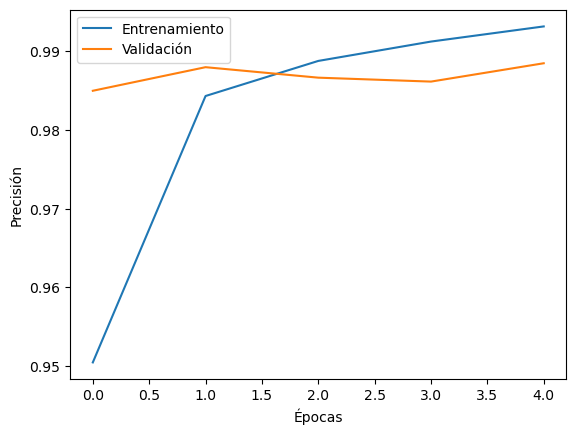

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Cargar datos del dataset MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocesamiento
x_train = x_train.reshape((60000, 28, 28, 1)) / 255.0
x_test = x_test.reshape((10000, 28, 28, 1)) / 255.0

# Arquitectura del Modelo CNN
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compilar el modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# Evaluación del rendimiento
test_loss, test_acc = model.evaluate(x_test, y_test)
print("\nPrecisión en datos de prueba:", test_acc)

# Gráfica de convergencia
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

https://github.com/reromash1/machines2